# Churn Prediction

We predict, as of a fixed cutoff date, which currently-active accounts
will go dark (zero accepted shipments) over the following 6 months --
see `01_data_generation` for the leakage-safe cutoff/label design.
Retention/Sales can use this to prioritize outreach before an account is
actually gone, rather than noticing only after the fact.

Note: `true_beta` (the simulator's hidden price-sensitivity parameter)
is intentionally **excluded** from the feature set -- a real pricing
team never observes a customer's underlying elasticity directly, only
behavior. Using it here would be leaking ground truth into the model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                              precision_recall_curve, confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import sys, os

sys.path.append(os.getcwd())
from config import DATA_DIR, FIG_DIR, CATEGORICAL, STATUS, INK, SEGMENT_ORDER, RANDOM_SEED, set_style

set_style()
FIG_SUBDIR = os.path.join(FIG_DIR, "04_churn")
os.makedirs(FIG_SUBDIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_DIR, "churn_labels.csv"))
df = df.rename(columns={"true_segment": "segment"})
print(f"churn_labels: {df.shape}, churn rate: {df['churned'].mean():.1%}")
df.head()

churn_labels: (2754, 16), churn rate: 10.6%

,customer_id,segment,true_beta,signup_date,industry,region,contract_type,tenure_days_at_cutoff,n_quotes_12m,n_accepted_12m,avg_price_ratio_12m,revenue_12m,express_share_12m,acceptance_rate_12m,price_ratio_trend,churned
0,1,SMB,8.548,2023-09-14,Pharma,West,Spot,706,3.0,3.0,1.02490,233.35,0.000000,1.0,0.103,0
1,2,SMB,7.251,2023-03-04,Industrial,West,Spot,900,5.0,5.0,0.98718,947.09,0.200000,1.0,NaN,0
2,3,Occasional,10.284,2023-05-12,Apparel,Northeast,Spot,831,2.0,2.0,0.96345,104.83,0.000000,1.0,NaN,0
3,4,SMB,10.525,2021-05-21,Retail,Southeast,Spot,1552,5.0,2.0,1.07238,396.57,0.200000,0.4,NaN,0
4,5,Mid-Market,4.554,2024-12-04,Apparel,Midwest,Spot,259,7.0,7.0,0.95410,917.65,0.285714,1.0,NaN,0


## 1. Features & split

Numeric behavioral features from the 12 months before the cutoff, plus
static account attributes. `price_ratio_trend` is missing for accounts
without enough history in the early part of the window -- we keep it as
a genuine missing value (not zero-imputed) and let the gradient-boosted
model's native missing-value handling deal with it; a `trend_missing`
flag captures the "not enough history" signal separately.

In [2]:
df["trend_missing"] = df["price_ratio_trend"].isna().astype(int)

num_features = ["tenure_days_at_cutoff", "n_quotes_12m", "n_accepted_12m",
                 "acceptance_rate_12m", "avg_price_ratio_12m", "revenue_12m",
                 "express_share_12m", "price_ratio_trend", "trend_missing"]
cat_features = ["segment", "industry", "region", "contract_type"]
target = "churned"

X = df[num_features + cat_features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y)
print(f"Train: {X_train.shape[0]:,} ({y_train.mean():.1%} churn)  |  Test: {X_test.shape[0]:,} ({y_test.mean():.1%} churn)")

Train: 2,065 (10.6% churn)  |  Test: 689 (10.6% churn)

## 2. Baseline (logistic regression) vs. gradient boosting

In [3]:
gbm_pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
], remainder="passthrough")
gbm_pipe = Pipeline([("pre", gbm_pre), ("clf", HistGradientBoostingClassifier(
    max_depth=4, learning_rate=0.06, max_iter=300, random_state=RANDOM_SEED))])
gbm_pipe.fit(X_train, y_train)

logit_pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_features),
])
logit_pipe = Pipeline([("pre", logit_pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
logit_pipe.fit(X_train, y_train)

results = {}
for name, m in [("Logistic Regression", logit_pipe), ("Gradient Boosting", gbm_pipe)]:
    p = m.predict_proba(X_test)[:, 1]
    results[name] = dict(roc_auc=roc_auc_score(y_test, p), pr_auc=average_precision_score(y_test, p))
results_df = pd.DataFrame(results).T
print(results_df.round(4))
model = gbm_pipe

                     roc_auc  pr_auc
Logistic Regression   0.8436  0.3623
Gradient Boosting     0.8313  0.3183

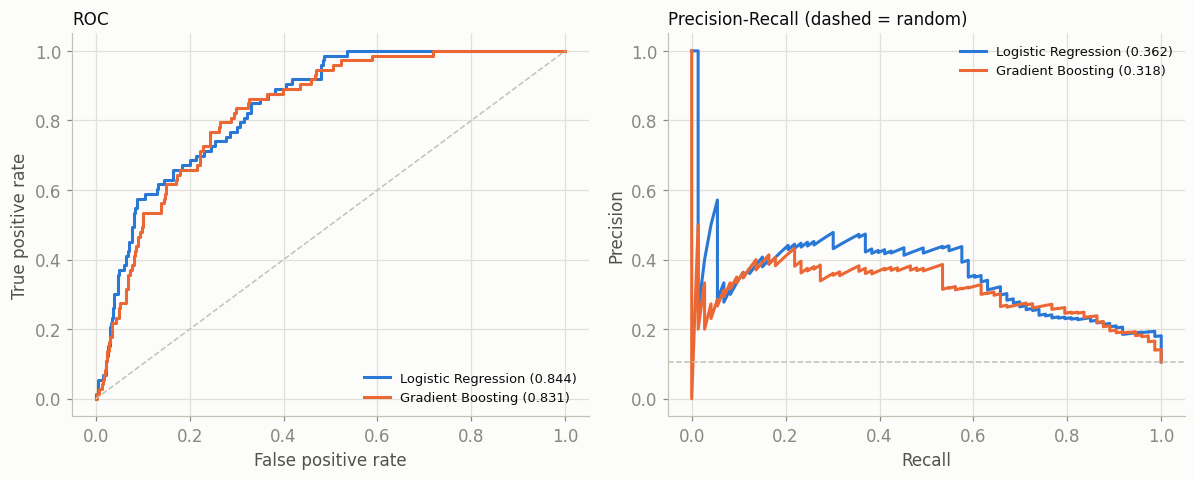

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for i, (name, m) in enumerate([("Logistic Regression", logit_pipe), ("Gradient Boosting", gbm_pipe)]):
    p = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=CATEGORICAL[i], linewidth=2, label=f"{name} ({results[name]['roc_auc']:.3f})")
    axes[1].plot(rec, prec, color=CATEGORICAL[i], linewidth=2, label=f"{name} ({results[name]['pr_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], color=INK["baseline"], linestyle="--", linewidth=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC", loc="left", fontsize=11)
axes[0].legend(frameon=False, fontsize=8.5, loc="lower right")
base_rate = y_test.mean()
axes[1].axhline(base_rate, color=INK["baseline"], linestyle="--", linewidth=1)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall (dashed = random)", loc="left", fontsize=11)
axes[1].legend(frameon=False, fontsize=8.5, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "01_roc_pr_curves.png"), bbox_inches="tight")
plt.show()

## 3. Decile / lift analysis

Rank test-set accounts by predicted churn risk and bucket into deciles.
This is the view Retention actually cares about: "if we can only call
the top 20% highest-risk accounts, what share of real churners do we
catch?"

In [5]:
test_scored = X_test.copy()
test_scored["churned"] = y_test.values
test_scored["risk_score"] = model.predict_proba(X_test)[:, 1]
test_scored["decile"] = pd.qcut(test_scored["risk_score"].rank(method="first"), 10, labels=False) + 1
test_scored["decile"] = 11 - test_scored["decile"]  # 1 = highest risk

decile_summary = test_scored.groupby("decile").agg(
    n=("churned", "size"), churners=("churned", "sum"), churn_rate=("churned", "mean")
).sort_index()
decile_summary["cum_churners"] = decile_summary["churners"].cumsum()
decile_summary["cum_capture_rate"] = decile_summary["cum_churners"] / decile_summary["churners"].sum()
top20_capture = decile_summary.loc[[1, 2], "churners"].sum() / decile_summary["churners"].sum()
print(f"Calling the top 2 deciles (20% of accounts) catches {top20_capture:.0%} of actual churners.")
decile_summary

Calling the top 2 deciles (20% of accounts) catches 62% of actual churners.

,n,churners,churn_rate,cum_churners,cum_capture_rate
decile,,,,,
1,69,26,0.376812,26,0.356164
2,69,19,0.275362,45,0.616438
3,69,11,0.159420,56,0.767123
4,69,7,0.101449,63,0.863014
5,68,3,0.044118,66,0.904110
6,69,5,0.072464,71,0.972603
7,69,1,0.014493,72,0.986301
8,69,1,0.014493,73,1.000000
9,69,0,0.000000,73,1.000000


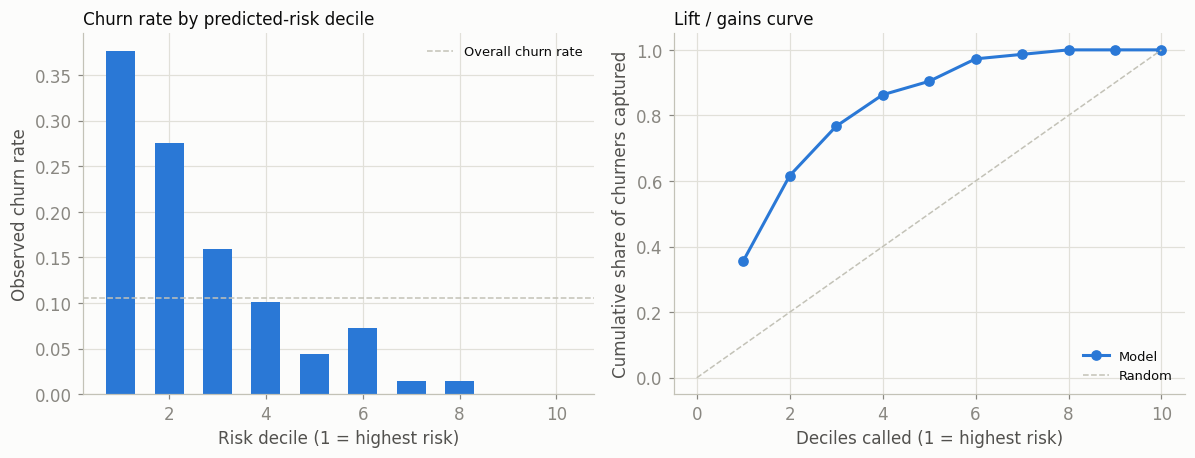

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar(decile_summary.index, decile_summary["churn_rate"], color=CATEGORICAL[0], width=0.6)
axes[0].axhline(base_rate, color=INK["baseline"], linestyle="--", linewidth=1, label="Overall churn rate")
axes[0].set_xlabel("Risk decile (1 = highest risk)")
axes[0].set_ylabel("Observed churn rate")
axes[0].set_title("Churn rate by predicted-risk decile", loc="left", fontsize=11)
axes[0].legend(frameon=False, fontsize=8.5)

axes[1].plot(decile_summary.index, decile_summary["cum_capture_rate"], marker="o",
             color=CATEGORICAL[0], linewidth=2, label="Model")
axes[1].plot([0, 10], [0, 1], color=INK["baseline"], linestyle="--", linewidth=1, label="Random")
axes[1].set_xlabel("Deciles called (1 = highest risk)")
axes[1].set_ylabel("Cumulative share of churners captured")
axes[1].set_title("Lift / gains curve", loc="left", fontsize=11)
axes[1].legend(frameon=False, fontsize=8.5, loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "02_decile_lift.png"), bbox_inches="tight")
plt.show()

## 4. Feature importance & partial dependence

segment                0.187353
price_ratio_trend      0.013646
n_quotes_12m           0.010936
revenue_12m            0.009379
n_accepted_12m         0.008848
avg_price_ratio_12m    0.007772
region                 0.004236
contract_type          0.000898
dtype: float64

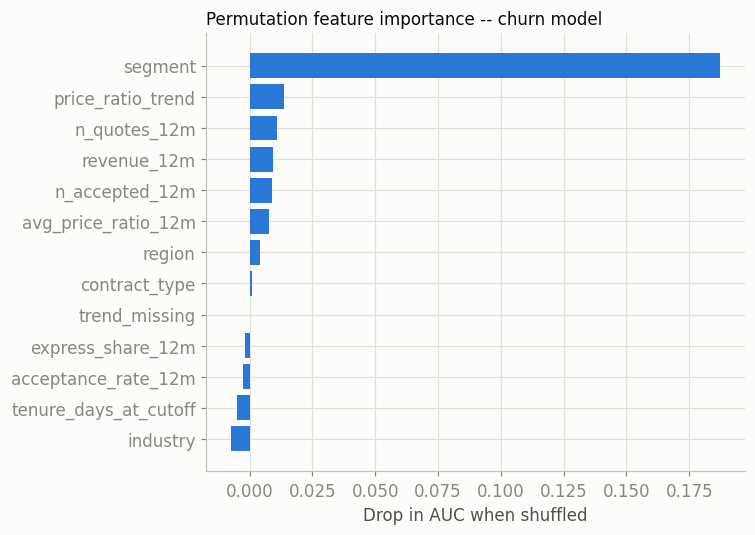

In [7]:
perm = permutation_importance(model, X_test, y_test, scoring="roc_auc",
                               n_repeats=8, random_state=RANDOM_SEED, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp.index, imp.values, color=CATEGORICAL[0])
ax.set_xlabel("Drop in AUC when shuffled")
ax.set_title("Permutation feature importance -- churn model", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "03_feature_importance.png"), bbox_inches="tight")
plt.show()
imp.sort_values(ascending=False).head(8)

/usr/local/lib/python3.11/dist-packages/sklearn/inspection/_plot/partial_dependence.py:990: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])

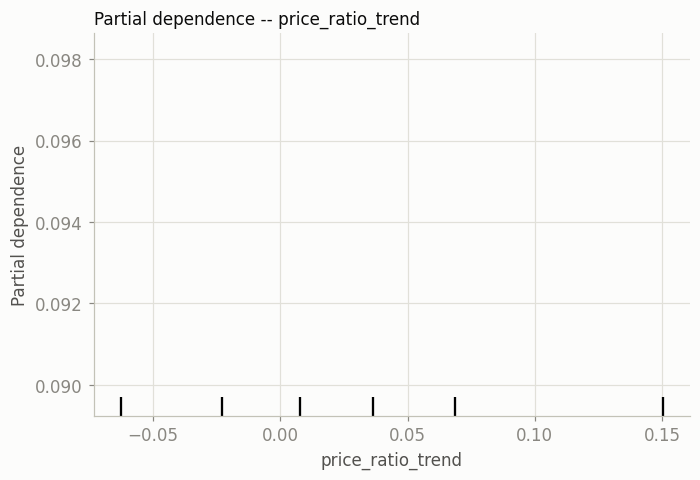

In [8]:
# `segment` is the single strongest predictor (by a wide margin -- see
# above), but it's categorical, so we show its effect as a bar chart in
# section 5 instead. For partial dependence (which needs a continuous
# axis to sweep) we use the strongest *numeric* feature.
top_feat = imp[num_features].idxmax()
fig, ax = plt.subplots(figsize=(6.5, 4.5))
PartialDependenceDisplay.from_estimator(model, X_test, [top_feat], ax=ax,
                                         line_kw={"color": CATEGORICAL[0], "linewidth": 2.2})
ax.set_title(f"Partial dependence -- {top_feat}", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "04_partial_dependence.png"), bbox_inches="tight")
plt.show()

## 5. Churn rate by segment (business view)

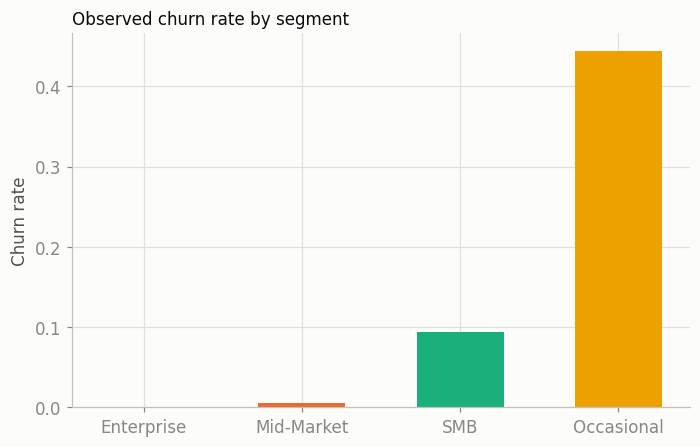

In [9]:
seg_churn = df.groupby("segment")["churned"].mean().reindex(SEGMENT_ORDER)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(seg_churn.index, seg_churn.values,
       color=[CATEGORICAL[i] for i in range(len(seg_churn))], width=0.55)
ax.set_ylabel("Churn rate")
ax.set_title("Observed churn rate by segment", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "05_churn_by_segment.png"), bbox_inches="tight")
plt.show()

## 6. Save scored book (for the dashboard) & metrics

In [10]:
full_scores = df[["customer_id", "segment", "churned"]].copy()
full_scores["risk_score"] = model.predict_proba(X)[:, 1]
full_scores.to_csv(os.path.join(DATA_DIR, "churn_risk_scores.csv"), index=False)
results_df.to_csv(os.path.join(DATA_DIR, "churn_model_metrics.csv"))
decile_summary.to_csv(os.path.join(DATA_DIR, "churn_decile_summary.csv"))
print("Saved churn_risk_scores.csv, churn_model_metrics.csv, churn_decile_summary.csv")

Saved churn_risk_scores.csv, churn_model_metrics.csv, churn_decile_summary.csv